# atlm_pro — Dataset Exploration

**Project goal.** Fine-tune a small instruction model (SmolLM) so that a
recruiter's loose requirements — e.g. *"I need a job description for someone who
knows Java, pipelines and CI/CD"* — produce a complete, well-formatted job
description.

**This notebook** explores the candidate datasets and justifies which one(s) the
project will use. Two datasets are examined:

1. **Djinni** — real IT job postings (`lang-uk/recruitment-dataset-job-descriptions-english`, Hugging Face, MIT licence).
2. **LinkedIn** — real cross-industry job postings (Kaggle, 2023–2024).

The notebook is structured as follows:

| Section | Scope |
|---------|-------|
| 0. Setup | imports, paths |
| 1. Load datasets | read files, shape summary |
| 2. Djinni — deep dive | all Djinni-specific analysis |
| 3. LinkedIn — deep dive | all LinkedIn-specific analysis |
| 4. Comparative analysis | side-by-side metrics across both datasets |
| 5. Prompt-readiness & recommendations | training implications |


## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

# Locate the project root (the folder that contains data/).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
JOBS = PROJECT_ROOT / "data" / "jobs"

print("Project root :", PROJECT_ROOT)
print("Jobs data dir:", JOBS)
assert JOBS.exists(), f"data/jobs not found starting from {Path.cwd()}"

Project root : c:\Users\user\Desktop\ISCTE\ATLM\Projeto\atlm_pro
Jobs data dir: c:\Users\user\Desktop\ISCTE\ATLM\Projeto\atlm_pro\data\jobs


## 1. Load datasets

Both datasets are loaded here and a top-level shape summary is produced.
All exploratory analysis follows in the dedicated sections below.


In [2]:
# ── Djinni ───────────────────────────────────────────────────────────────────
djinni = pd.read_parquet(JOBS / "djinni" / "train-00000-of-00001.parquet")
djinni = djinni.drop(columns=["__index_level_0__"], errors="ignore")

# ── LinkedIn ─────────────────────────────────────────────────────────────────
linkedin_keep = ["job_id", "title", "description", "company_name", "location",
                 "formatted_work_type", "formatted_experience_level", "skills_desc"]
linkedin = pd.read_csv(JOBS / "linkedin" / "postings.csv", usecols=linkedin_keep)

# ── Summary ──────────────────────────────────────────────────────────────────
datasets = {"Djinni": djinni, "LinkedIn": linkedin}

pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows":    [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
})


,Dataset,Rows,Columns
0,Djinni,141897,9
1,LinkedIn,123849,8


## 2. Djinni - the core dataset

[`lang-uk/recruitment-dataset-job-descriptions-english`](https://huggingface.co/datasets/lang-uk/recruitment-dataset-job-descriptions-english)
— real IT job postings scraped from the Djinni platform (2020–2023).

This is the **core training dataset**. The analysis below covers:
- schema & missing values
- primary keyword (tech domain) distribution
- target text (`Long Description`) quality and length
- structured prompt features: experience level, English level
- description length vs. seniority
- repetition / template detection


### 2.1 Schema and missing values

In [3]:
print(f"Shape: {djinni.shape[0]:,} rows × {djinni.shape[1]} columns\n")

schema = pd.DataFrame({
    "dtype":      [djinni[c].dtype for c in djinni.columns],
    "non_null":   [djinni[c].notna().sum() for c in djinni.columns],
    "missing_%":  [(djinni[c].isna().mean() * 100).round(2) for c in djinni.columns],
    "n_unique":   [djinni[c].nunique() for c in djinni.columns],
}, index=djinni.columns)

display(schema)


Shape: 141,897 rows × 9 columns



,dtype,non_null,missing_%,n_unique
Position,str,141897,0.00,69671
Long Description,str,141897,0.00,141897
Company Name,str,141897,0.00,10894
Exp Years,str,141897,0.00,5
Primary Keyword,str,141897,0.00,45
English Level,str,134358,5.31,5
Published,str,141897,0.00,45
Long Description_lang,str,141897,0.00,1
id,str,141897,0.00,141897


### 2.2 Primary keyword (tech domain) distribution

`Primary Keyword` is the main structured signal for prompting:
it labels the tech stack or domain of each posting.


45 distinct primary keywords



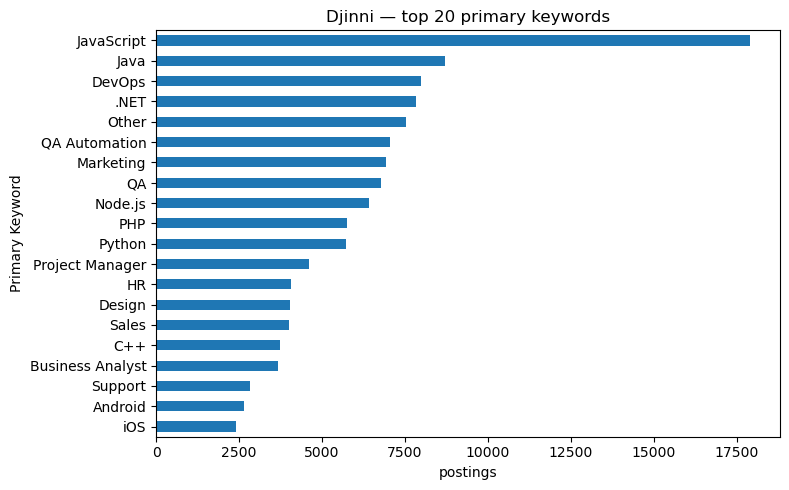

,keyword,postings
0,JavaScript,17903
1,Java,8712
2,DevOps,7979
3,.NET,7826
4,Other,7536
5,QA Automation,7047
6,Marketing,6933
7,QA,6774
8,Node.js,6416
9,PHP,5740


In [4]:
kw = djinni["Primary Keyword"].value_counts()
print(f"{kw.size} distinct primary keywords\n")

ax = kw.head(20).iloc[::-1].plot.barh(
    figsize=(8, 5), title="Djinni — top 20 primary keywords")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

# Full list for reference
display(kw.reset_index().rename(columns={"Primary Keyword": "keyword", "count": "postings"}))


### 2.3 Target text quality (`Long Description`)

Key questions: How many non-null, unique descriptions are there?
What is the length distribution?


Non-null descriptions : 141,897  (100.0%)
Unique descriptions   : 141,897  (100.0%)
Duplicate ratio       : 0.000

Length in characters:
count    141897.0
mean       1801.0
std         973.0
min          51.0
25%        1109.0
50%        1629.0
75%        2284.0
max       12578.0
Name: Long Description, dtype: float64


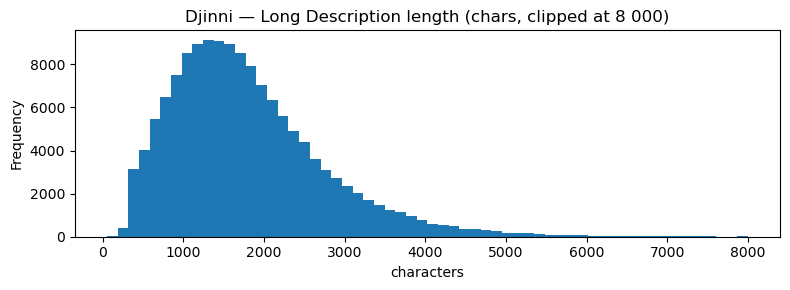

In [5]:
text = djinni["Long Description"].dropna().astype(str)

print(f"Non-null descriptions : {len(text):,}  ({len(text)/len(djinni):.1%})")
print(f"Unique descriptions   : {text.nunique():,}  ({text.nunique()/len(text):.1%})")
print(f"Duplicate ratio       : {1 - text.nunique()/len(text):.3f}\n")
print("Length in characters:")
print(text.str.len().describe().round(0))

ax = text.str.len().clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="Djinni — Long Description length (chars, clipped at 8 000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()


### 2.4 Structured prompt features: experience level and English level

`Exp Years` and `English Level` are the two categorical fields that can be used
alongside `Primary Keyword` to build richer prompts.
This section characterises their distributions and coverage in one place.


,Feature,Non-null,Non-null %,N distinct,Values
0,Exp Years,141897,100.00,5,"2y, 5y, 1y, 3y, no_exp"
1,English Level,134358,94.69,5,"intermediate, fluent, upper, pre, basic"


Exp Years_clean
3y        49996
2y        36150
5y        27772
1y        22007
no_exp     5972
Name: count, dtype: int64

English Level_clean
upper           66948
intermediate    54965
fluent          10583
NaN              7539
pre              1689
basic             173
Name: count, dtype: int64

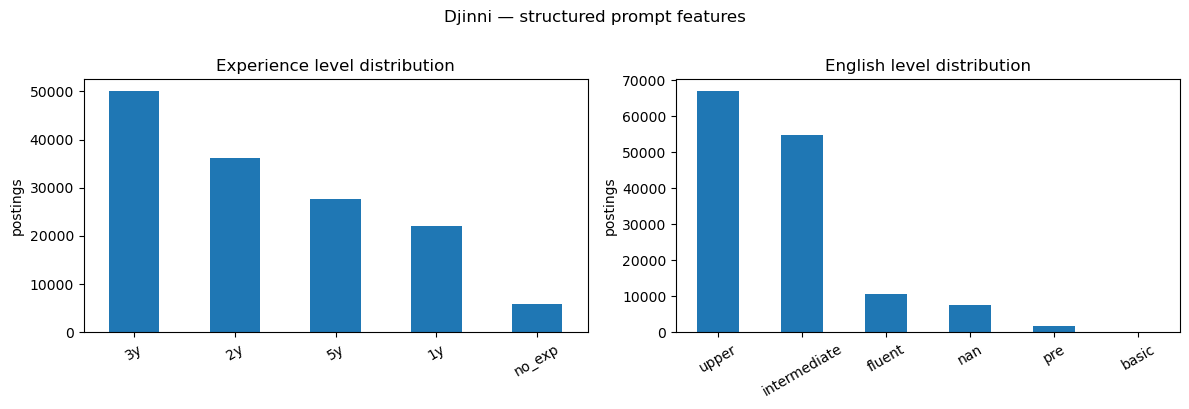

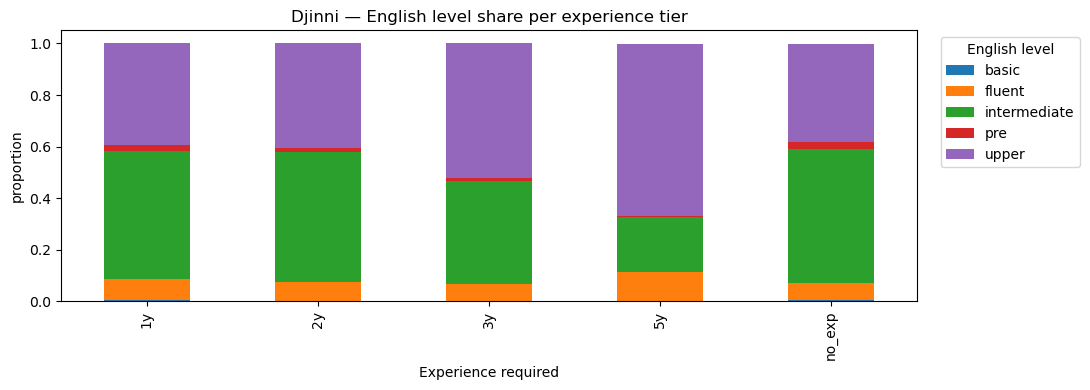

English Level_clean,basic,fluent,intermediate,pre,upper
Exp Years_clean,,,,,
1y,0.003,0.084,0.496,0.024,0.394
2y,0.001,0.072,0.506,0.017,0.404
3y,0.001,0.064,0.403,0.008,0.524
5y,0.001,0.112,0.214,0.004,0.668
no_exp,0.003,0.069,0.519,0.026,0.382


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Clean values
djinni["Exp Years_clean"] = djinni["Exp Years"].astype(str).str.strip()
djinni["English Level_clean"] = djinni["English Level"].astype(str).str.strip()

# Remove fake nan strings
djinni.loc[djinni["Exp Years"].isna(), "Exp Years_clean"] = pd.NA
djinni.loc[djinni["English Level"].isna(), "English Level_clean"] = pd.NA

# Coverage
cov = pd.DataFrame({
    "Feature": ["Exp Years", "English Level"],
    "Non-null": [
        djinni["Exp Years"].notna().sum(),
        djinni["English Level"].notna().sum()
    ],
    "Non-null %": [
        round(djinni["Exp Years"].notna().mean() * 100, 2),
        round(djinni["English Level"].notna().mean() * 100, 2)
    ],
    "N distinct": [
        djinni["Exp Years_clean"].nunique(dropna=True),
        djinni["English Level_clean"].nunique(dropna=True)
    ],
    "Values": [
        ", ".join(djinni["Exp Years_clean"].dropna().unique().astype(str)),
        ", ".join(djinni["English Level_clean"].dropna().unique().astype(str))
    ]
})

display(cov)

# Real distributions
exp_counts = djinni["Exp Years_clean"].value_counts(dropna=False)
eng_counts = djinni["English Level_clean"].value_counts(dropna=False)

display(exp_counts)
display(eng_counts)

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not exp_counts.empty:
    exp_counts.plot.bar(ax=axes[0], rot=30)
    axes[0].set_title("Experience level distribution")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("postings")
else:
    axes[0].text(0.5, 0.5, "No Exp Years data", ha="center", va="center")
    axes[0].set_axis_off()

if not eng_counts.empty:
    eng_counts.plot.bar(ax=axes[1], rot=30)
    axes[1].set_title("English level distribution")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("postings")
else:
    axes[1].text(0.5, 0.5, "No English Level data", ha="center", va="center")
    axes[1].set_axis_off()

plt.suptitle("Djinni — structured prompt features", y=1.01)
plt.tight_layout()
plt.show()

# Cross-tab
ct = pd.crosstab(
    djinni["Exp Years_clean"],
    djinni["English Level_clean"],
    normalize="index"
).round(3)

if ct.empty:
    print("Cross-tab is empty. There is no overlap between Exp Years and English Level.")
else:
    ax = ct.plot.bar(
        figsize=(11, 4),
        stacked=True,
        title="Djinni — English level share per experience tier"
    )
    ax.set_xlabel("Experience required")
    ax.set_ylabel("proportion")
    ax.legend(title="English level", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    display(ct)

### 2.5 Description length vs. seniority

Does experience level influence how verbose a job description is?
This is relevant because the model should calibrate output length to the prompt.


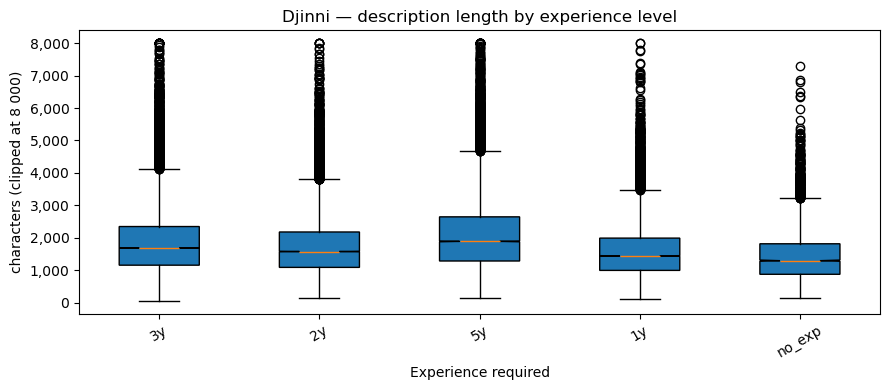

,n,mean,median
Exp Years_clean,,,
3y,49996,1845.0,1685.0
2y,36150,1721.0,1574.0
5y,27772,2076.0,1887.0
1y,22007,1579.0,1437.0
no_exp,5972,1445.0,1292.0


In [10]:
djinni["desc_len"] = djinni["Long Description"].astype(str).str.len()
djinni["Exp Years_clean"] = djinni["Exp Years"].astype(str).str.strip()

# Usar os valores reais existentes no dataset
present_exp = djinni["Exp Years_clean"].dropna().value_counts().index.tolist()

box_data = []

for e in present_exp:
    values = (
        djinni.loc[djinni["Exp Years_clean"] == e, "desc_len"]
        .clip(upper=8000)
        .dropna()
        .to_numpy()
    )
    
    if len(values) > 0:
        box_data.append(values)

if len(box_data) == 0:
    print("No valid data available for boxplot.")
    display(djinni["Exp Years"].value_counts(dropna=False))
else:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.boxplot(
        box_data,
        tick_labels=present_exp,
        notch=True,
        patch_artist=True
    )

    ax.set_title("Djinni — description length by experience level")
    ax.set_xlabel("Experience required")
    ax.set_ylabel("characters (clipped at 8 000)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    exp_stats = (
        djinni[djinni["Exp Years_clean"].isin(present_exp)]
        .groupby("Exp Years_clean")["desc_len"]
        .agg(n="count", mean="mean", median="median")
        .round(0)
        .reindex(present_exp)
    )

    display(exp_stats)

### 2.6 Repetition and template detection

Does the same keyword always produce the same description, or is there genuine
variety per tech domain?
A low diversity score (≈1 distinct description per keyword) would indicate
a lookup-table dataset rather than a true language-generation resource.


In [11]:
diversity = (
    djinni.groupby("Primary Keyword")["Long Description"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="distinct_descriptions")
)

print("Distinct descriptions per keyword — summary:")
display(diversity.describe().round(0))
print("\nTop 15 keywords by description variety:")
display(diversity.head(15))


Distinct descriptions per keyword — summary:


,distinct_descriptions
count,45.0
mean,3153.0
std,3472.0
min,1.0
25%,554.0
50%,1861.0
75%,4618.0
max,17903.0



Top 15 keywords by description variety:


,Primary Keyword,distinct_descriptions
0,JavaScript,17903
1,Java,8712
2,DevOps,7979
3,.NET,7826
4,Other,7536
5,QA Automation,7047
6,Marketing,6933
7,QA,6774
8,Node.js,6416
9,PHP,5740


## 3. LinkedIn - out-of-domain test set

[Kaggle: LinkedIn Job Postings 2023–2024](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)
— real, cross-industry postings.

This dataset is held out **entirely from training** and used only to measure
how well an IT-trained model generalises to other domains.

The analysis below covers:
- schema & missing values
- target text (`description`) quality and length
- job title and industry distribution
- structured metadata coverage
- repetition / template detection


### 3.1 Schema and missing values

In [12]:
print(f"Shape: {linkedin.shape[0]:,} rows × {linkedin.shape[1]} columns\n")

schema_li = pd.DataFrame({
    "dtype":     [linkedin[c].dtype for c in linkedin.columns],
    "non_null":  [linkedin[c].notna().sum() for c in linkedin.columns],
    "missing_%": [(linkedin[c].isna().mean() * 100).round(2) for c in linkedin.columns],
    "n_unique":  [linkedin[c].nunique() for c in linkedin.columns],
}, index=linkedin.columns)

display(schema_li)


Shape: 123,849 rows × 8 columns



,dtype,non_null,missing_%,n_unique
job_id,int64,123849,0.00,123849
company_name,str,122130,1.39,24428
title,str,123849,0.00,72521
description,str,123842,0.01,107827
location,str,123849,0.00,8526
formatted_work_type,str,123849,0.00,7
formatted_experience_level,str,94440,23.75,6
skills_desc,str,2439,98.03,2212


### 3.2 Target text quality (`description`)


Non-null descriptions : 123,842  (100.0%)
Unique descriptions   : 107,827  (87.1%)
Duplicate ratio       : 0.129

Length in characters:
count    123842.0
mean       3766.0
std        2146.0
min           2.0
25%        2176.0
50%        3435.0
75%        4986.0
max       23201.0
Name: description, dtype: float64


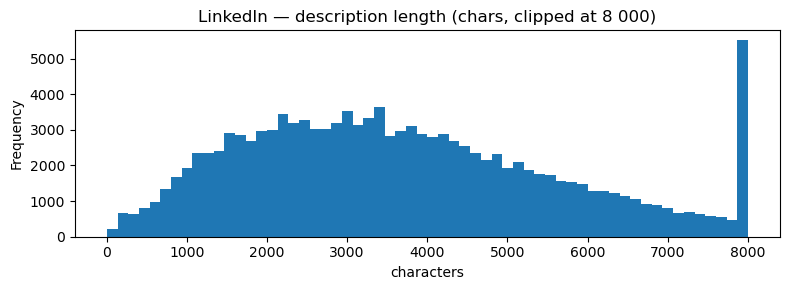

In [13]:
li_text = linkedin["description"].dropna().astype(str)

print(f"Non-null descriptions : {len(li_text):,}  ({len(li_text)/len(linkedin):.1%})")
print(f"Unique descriptions   : {li_text.nunique():,}  ({li_text.nunique()/len(li_text):.1%})")
print(f"Duplicate ratio       : {1 - li_text.nunique()/len(li_text):.3f}\n")
print("Length in characters:")
print(li_text.str.len().describe().round(0))

ax = li_text.str.len().clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="LinkedIn — description length (chars, clipped at 8 000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()


### 3.3 Job family distribution

LinkedIn spans all industries. A keyword-based taxonomy groups job titles into
broad families to reveal how balanced (or skewed) the out-of-domain test set is.


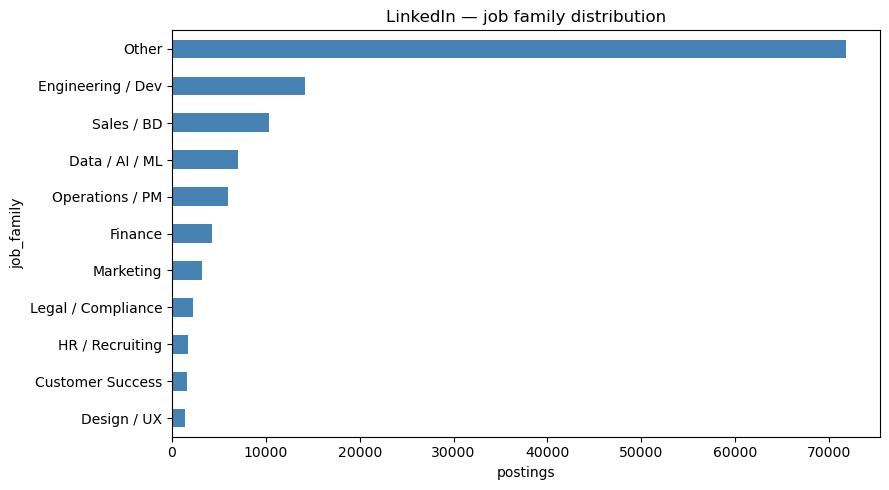

,family,postings
0,Other,71850
1,Engineering / Dev,14207
2,Sales / BD,10327
3,Data / AI / ML,7056
4,Operations / PM,6014
5,Finance,4219
6,Marketing,3153
7,Legal / Compliance,2258
8,HR / Recruiting,1700
9,Customer Success,1644


In [14]:
import re

family_map = {
    "Engineering / Dev":  r"engineer|developer|software|backend|frontend|fullstack|devops|sre|cloud",
    "Data / AI / ML":     r"data |machine learning|analyst|scientist|analytics|\bbi\b|nlp|llm|\bai\b",
    "Design / UX":        r"design|ux |ui |product design|creative",
    "Marketing":          r"market|seo|growth|brand|content|social media|copywriter",
    "Sales / BD":         r"sales|account exec|business dev|account manager",
    "Finance":            r"finance|accountant|financi|controller|audit|\btax\b",
    "HR / Recruiting":    r"recruiter|talent|human resource|\bhr\b|people ops",
    "Operations / PM":    r"operat|product manager|project manager|scrum|agile|supply",
    "Customer Success":   r"customer success|support|\bcx\b|service desk|helpdesk",
    "Legal / Compliance": r"legal|counsel|compliance|attorney|paralegal",
}

def classify_title(title):
    t = str(title).lower()
    for family, pattern in family_map.items():
        if re.search(pattern, t):
            return family
    return "Other"

linkedin["job_family"] = linkedin["title"].map(classify_title)
family_counts = linkedin["job_family"].value_counts()

ax = family_counts.sort_values().plot.barh(
    figsize=(9, 5), color="steelblue",
    title="LinkedIn — job family distribution")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

display(family_counts.reset_index().rename(columns={"job_family": "family", "count": "postings"}))


### 3.4 Structured metadata coverage

Which LinkedIn fields can realistically be used as prompt inputs or evaluation
filters?


In [15]:
meta_cols = ["title", "formatted_work_type", "formatted_experience_level",
             "location", "company_name", "skills_desc"]

meta = pd.DataFrame({
    "Feature":    meta_cols,
    "Non-null %": [(linkedin[c].notna().mean() * 100).round(2) for c in meta_cols],
    "N distinct": [linkedin[c].nunique() for c in meta_cols],
    "Example values": [
        ", ".join(linkedin[c].dropna().astype(str).unique()[:4])
        for c in meta_cols
    ],
})
display(meta)


,Feature,Non-null %,N distinct,Example values
0,title,100.00,72521,"Marketing Coordinator, Mental Health Therapist/Counselor, Assitant Restaurant Manager, Senior Elder Law / Trusts and..."
1,formatted_work_type,100.00,7,"Full-time, Internship, Contract, Part-time"
2,formatted_experience_level,76.25,6,"Entry level, Mid-Senior level, Associate, Director"
3,location,100.00,8526,"Princeton, NJ, Fort Collins, CO, Cincinnati, OH, New Hyde Park, NY"
4,company_name,98.61,24428,"Corcoran Sawyer Smith, The National Exemplar , Abrams Fensterman, LLP, Downtown Raleigh Alliance"
5,skills_desc,1.97,2212,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...


### 3.5 Repetition and template detection


In [16]:
li_div = (
    linkedin.dropna(subset=["title", "description"])
    .groupby("title")["description"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="distinct_descriptions")
)

print("Distinct descriptions per title — summary:")
display(li_div.describe().round(0))
print("\nTop 15 titles by description variety:")
display(li_div.head(15))


Distinct descriptions per title — summary:


,distinct_descriptions
count,72516.0
mean,2.0
std,5.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,345.0



Top 15 titles by description variety:


,title,distinct_descriptions
0,Project Manager,345
1,Customer Service Representative,270
2,Administrative Assistant,243
3,Senior Accountant,234
4,Salesperson,204
5,Registered Nurse,201
6,Staff Accountant,197
7,Account Executive,183
8,Executive Assistant,178
9,Controller,168


## 4. Comparative analysis

Side-by-side metrics that directly compare Djinni and LinkedIn
on dimensions relevant to fine-tuning.


### 4.1 Target text quality

In [17]:
target_cols = {"Djinni": "Long Description", "LinkedIn": "description"}

rows_tq = []
for name, col in target_cols.items():
    t = datasets[name][col].dropna().astype(str)
    rows_tq.append({
        "Dataset":        name,
        "Target column":  col,
        "Non-null":       len(t),
        "Unique":         t.nunique(),
        "Duplicate ratio": round(1 - t.nunique() / len(t), 4),
        "Avg length":     round(t.str.len().mean(), 0),
        "Median length":  round(t.str.len().median(), 0),
        "Min length":     int(t.str.len().min()),
        "Max length":     int(t.str.len().max()),
    })

display(pd.DataFrame(rows_tq))


,Dataset,Target column,Non-null,Unique,Duplicate ratio,Avg length,Median length,Min length,Max length
0,Djinni,Long Description,141897,141897,0.0000,1801.0,1629.0,51,12578
1,LinkedIn,description,123842,107827,0.1293,3766.0,3435.0,2,23201


### 4.2 Lexical diversity

Lexical diversity (unique tokens / total tokens on a sample) measures how varied
the vocabulary is. Higher diversity → the model is exposed to richer language.


In [18]:
import re

def lexical_diversity(series, sample_size=5000):
    text = " ".join(
        series.dropna().astype(str).head(sample_size).str.lower().tolist()
    )
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]{2,}\b", text)
    if not words:
        return 0, 0, 0.0
    return len(words), len(set(words)), round(len(set(words)) / len(words), 4)

rows_ld = []
for name, col in target_cols.items():
    total, unique, ratio = lexical_diversity(datasets[name][col])
    rows_ld.append({
        "Dataset": name, "Column": col,
        "Total tokens (sample)": total,
        "Unique tokens": unique,
        "Lexical diversity": ratio,
    })

display(pd.DataFrame(rows_ld))


,Dataset,Column,Total tokens (sample),Unique tokens,Lexical diversity
0,Djinni,Long Description,1020803,22368,0.0219
1,LinkedIn,description,2059537,67524,0.0328


### 4.3 Most common terms

A qualitative view of the vocabulary each dataset uses most.


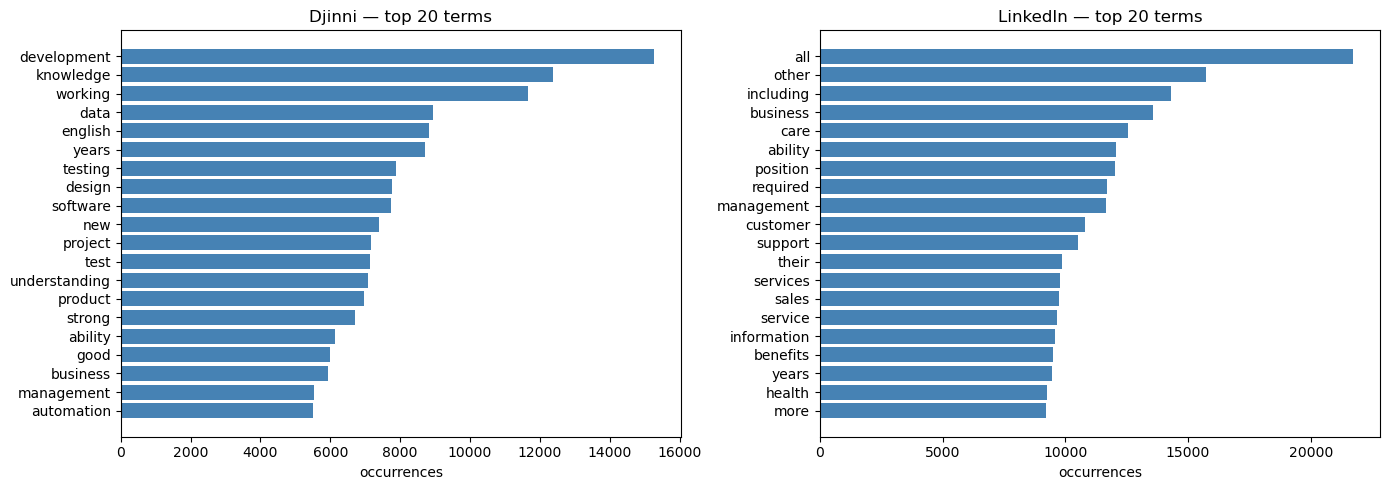

In [19]:
from collections import Counter

STOPWORDS = {
    "the", "and", "for", "with", "you", "are", "our", "will", "this", "that",
    "from", "have", "your", "job", "work", "team", "experience", "skills",
    "candidate", "company", "role", "responsibilities", "requirements"
}

def top_terms(series, n=20):
    text = " ".join(series.dropna().astype(str).head(10_000).str.lower())
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]{2,}\b", text)
    words = [w for w in words if w not in STOPWORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["term", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, col) in zip(axes, target_cols.items()):
    terms = top_terms(datasets[name][col])
    ax.barh(terms["term"][::-1], terms["count"][::-1], color="steelblue")
    ax.set_title(f"{name} — top 20 terms")
    ax.set_xlabel("occurrences")
plt.tight_layout()
plt.show()


## 5. Prompt-readiness and recommendations

### 5.1 Prompt-readiness score

A row is **prompt-ready** when the target description is non-null and ≥ 200 chars,
and at least one structured input feature is non-null.
This gives the realistic ceiling of usable `(prompt → completion)` pairs.


In [20]:
MIN_LEN = 200

rows_pr = []

# Djinni
has_desc = djinni["Long Description"].notna() & (djinni["Long Description"].str.len() >= MIN_LEN)
has_feat = djinni[["Primary Keyword", "Exp Years"]].notna().any(axis=1)
ready = has_desc & has_feat
rows_pr.append({
    "Dataset": "Djinni",
    "Total rows": len(djinni),
    "Prompt-ready rows": int(ready.sum()),
    "Ready %": round(ready.mean() * 100, 1),
    "Dropped — short/null desc": int((~has_desc).sum()),
    "Dropped — no feature": int((has_desc & ~has_feat).sum()),
})

# LinkedIn
has_desc_li = linkedin["description"].notna() & (linkedin["description"].str.len() >= MIN_LEN)
has_feat_li = linkedin[["title", "formatted_experience_level"]].notna().any(axis=1)
ready_li = has_desc_li & has_feat_li
rows_pr.append({
    "Dataset": "LinkedIn",
    "Total rows": len(linkedin),
    "Prompt-ready rows": int(ready_li.sum()),
    "Ready %": round(ready_li.mean() * 100, 1),
    "Dropped — short/null desc": int((~has_desc_li).sum()),
    "Dropped — no feature": int((has_desc_li & ~has_feat_li).sum()),
})

display(pd.DataFrame(rows_pr))


,Dataset,Total rows,Prompt-ready rows,Ready %,Dropped — short/null desc,Dropped — no feature
0,Djinni,141897,141859,100.0,38,0
1,LinkedIn,123849,123222,99.5,627,0


### 5.2 Recommendations

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Djinni is IT-only; LinkedIn spans all industries. | Use Djinni for train/val; LinkedIn as out-of-domain test only. |
| 2 | Description length is right-skewed (long tail > 5k chars) in both datasets. | Apply a max-token cap (~512–1024) during tokenisation, or truncate long descriptions. |
| 3 | `Exp Years` and `English Level` together cover > 95 % of Djinni rows and co-vary (see §2.4). | Include both as prompt fields; the cross-tab shows they add complementary signal. |
| 4 | `skills_desc` in LinkedIn has significant missingness (see §3.1). | Do not rely on `skills_desc` as a required field for LinkedIn evaluation. |
| 5 | Description length correlates with seniority in Djinni (§2.5). | Providing `Exp Years` in prompts helps the model calibrate output verbosity. |
| 6 | LinkedIn is dominated by Engineering/Dev and Data/AI (~50 % combined, §3.3). | The out-of-domain test is skewed; report per-family generalisation metrics separately. |


## 6. Skill → Role mapping analysis

This section is directly aligned with the project objective: **informal business requirements → inferred role → structured job description**.

Instead of only checking dataset size or missing values, we verify whether technical skills and domain terms are meaningfully associated with job roles. If this relationship exists, the dataset is suitable for teaching a language model to infer roles from loose recruiter or business-area descriptions.

**Implication for fine-tuning:** if skills such as `Figma`, `UX`, `Kubernetes`, `SQL`, `Azure`, or `CI/CD` consistently appear near specific job families, then the model can learn useful semantic mappings rather than memorising isolated templates.


Rows with ≥1 extracted skill : 123,823  (87.3%)
Total skill mentions         : 445,524


,skill,mentions
0,SQL,42268
1,JavaScript,42265
2,Cybersecurity,39478
3,Architecture,38469
4,Scrum/Agile,36949
5,CI/CD,28168
6,AWS,26930
7,UX/UI,24460
8,Docker,23535
9,React,23308


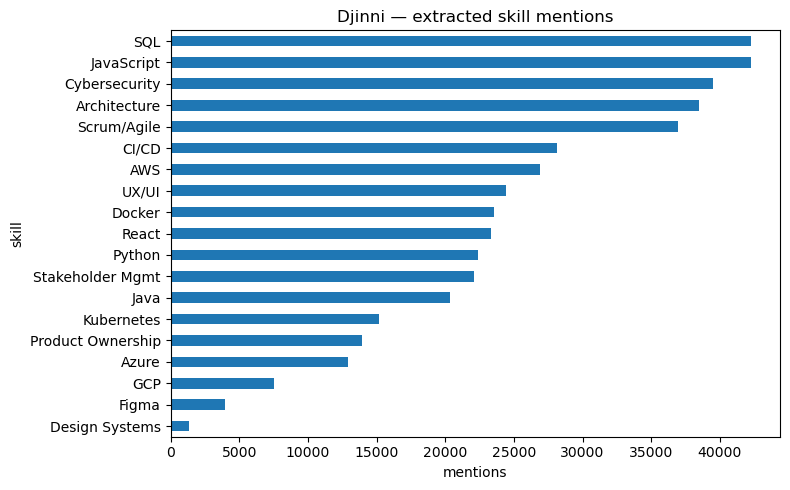

In [38]:
import re
from collections import Counter

SKILL_PATTERNS = {
    "Figma":                r"\bfigma\b",
    "UX/UI":                r"\bux\b|\bui\b|user experience|user interface",
    "Design Systems":       r"design system",
    "SQL":                  r"\bsql\b|postgres|mysql|sql server|oracle",
    "Azure":                r"\bazure\b",
    "AWS":                  r"\baws\b|amazon web services",
    "GCP":                  r"\bgcp\b|google cloud",
    "Kubernetes":           r"kubernetes|\bk8s\b",
    "Docker":               r"\bdocker\b|container",
    "CI/CD":                r"ci/cd|continuous integration|continuous delivery|pipeline",
    "Python":               r"\bpython\b",
    "Java":                 r"\bjava\b",
    "JavaScript":           r"javascript|\bjs\b|typescript|\bts\b",
    "React":                r"\breact\b|reactjs",
    "Scrum/Agile":          r"\bscrum\b|\bagile\b|kanban",
    "Product Ownership":    r"product owner|backlog|roadmap|user stories",
    "Cybersecurity":        r"security|cyber|siem|iam|vulnerabilit|soc",
    "Architecture":         r"architect|architecture|solution design",
    "Stakeholder Mgmt":     r"stakeholder|business team|cross-functional|multi[- ]team",
}

def extract_skills(text):
    t = str(text).lower()
    return [skill for skill, pat in SKILL_PATTERNS.items()
            if re.search(pat, t, flags=re.IGNORECASE)]

# ── Build skill_df with explode instead of iterrows ──────────────────────────
base = djinni.dropna(subset=["Long Description", "Primary Keyword"]).copy()
base["extracted_skills"] = base["Long Description"].apply(extract_skills)

# explode: one row per (description, skill) — no Python loop needed
skill_df = (
    base[["Primary Keyword", "extracted_skills"]]
    .explode("extracted_skills")
    .dropna(subset=["extracted_skills"])
    .rename(columns={"Primary Keyword": "role_or_domain", "extracted_skills": "skill"})
    .reset_index(drop=True)
)

n_with_skill = (base["extracted_skills"].str.len() > 0).sum()
print(f"Rows with ≥1 extracted skill : {n_with_skill:,}  ({n_with_skill/len(base):.1%})")
print(f"Total skill mentions         : {len(skill_df):,}")

if skill_df.empty:
    print("No skills extracted — check SKILL_PATTERNS against the actual vocabulary.")
else:
    top_skill_counts = skill_df["skill"].value_counts().reset_index()
    top_skill_counts.columns = ["skill", "mentions"]
    display(top_skill_counts)

    ax = top_skill_counts.head(20).iloc[::-1].plot.barh(
        x="skill", y="mentions", legend=False, figsize=(8, 5),
        title="Djinni — extracted skill mentions")
    ax.set_xlabel("mentions")
    plt.tight_layout()
    plt.show()



### 6.1 Most associated role/domain per skill

The table below answers a core project question: *when a business user mentions a skill, which role/domain is the dataset most likely to associate with it?*

This supports the role-inference part of the project. For example, if `Figma` and `UX/UI` concentrate around design-oriented roles, or `Kubernetes` and `CI/CD` around DevOps/cloud roles, the model has useful patterns to learn.


,skill,role_or_domain,count
9,AWS,DevOps,5206
13,AWS,Java,3198
18,AWS,Node.js,2982
54,Architecture,JavaScript,5162
53,Architecture,Java,4263
40,Architecture,.NET,3515
81,Azure,.NET,2936
90,Azure,DevOps,2625
95,Azure,JavaScript,919
130,CI/CD,DevOps,5689


role_or_domain,.NET,Business Analyst,Data Science,Design,DevOps,Java,JavaScript,Lead,Node.js,Other,PHP,Project Manager,Python,QA,QA Automation
skill,,,,,,,,,,,,,,,
AWS,1464,139,663,20,5206,3198,2691,598,2982,511,1185,132,2464,355,1167
Architecture,3515,767,622,419,2802,4263,5162,1320,2753,1171,1613,517,2168,1271,1464
CI/CD,1753,128,676,72,5689,2427,2742,460,1481,576,832,285,1624,646,2588
Cybersecurity,1753,630,481,953,3892,2845,4130,756,1898,1979,1241,772,1460,1299,1696
Docker,1569,57,290,11,5072,3350,2196,377,1927,312,1712,51,2095,329,1278
JavaScript,2970,151,141,358,987,2449,15905,580,5937,1148,3264,172,1500,937,2448
Python,305,204,1637,29,3941,913,992,386,494,586,312,87,5403,574,2028
React,1499,79,34,111,346,1310,11323,397,2724,598,1043,107,1015,282,461
SQL,4831,856,1255,30,2757,4990,2881,542,3272,1264,4000,164,3042,2662,2354


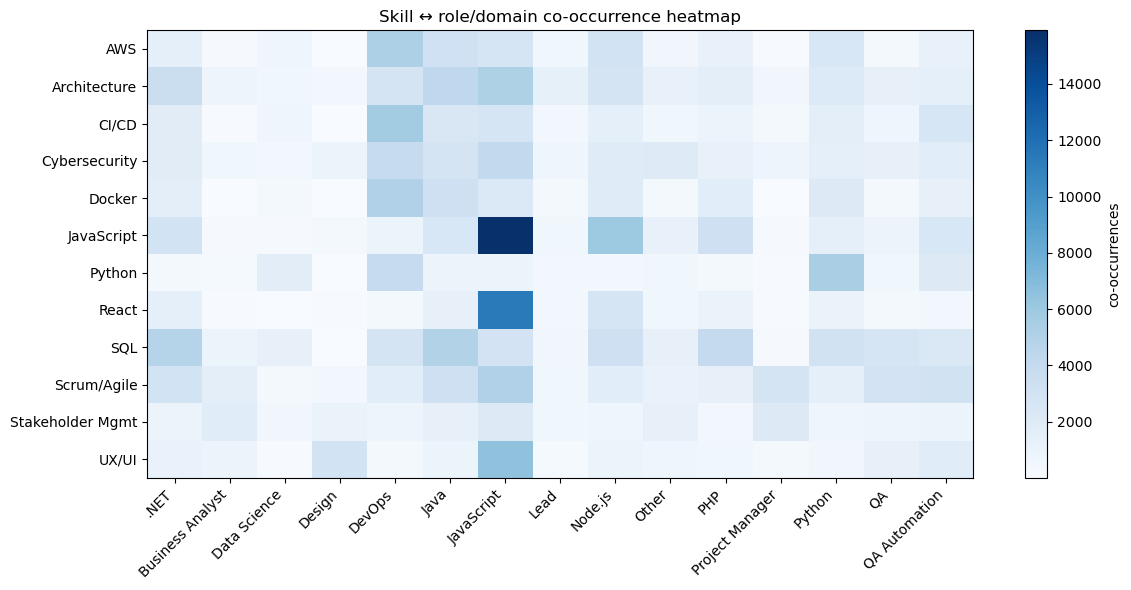

In [39]:
if not skill_df.empty:
    # Top-3 roles per skill
    skill_role = (
        skill_df.groupby(["skill", "role_or_domain"])
        .size()
        .reset_index(name="count")
        .sort_values(["skill", "count"], ascending=[True, False])
    )
    most_associated = skill_role.groupby("skill").head(3)
    display(most_associated)

    # Heatmap: use size() instead of count() on a text column
    top_skills = skill_df["skill"].value_counts().head(12).index
    top_roles  = skill_df["role_or_domain"].value_counts().head(15).index

    pivot = (
        skill_df[
            skill_df["skill"].isin(top_skills) &
            skill_df["role_or_domain"].isin(top_roles)
        ]
        .groupby(["skill", "role_or_domain"])
        .size()
        .unstack(fill_value=0)
    )
    display(pivot)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Skill ↔ role/domain co-occurrence heatmap")
    fig.colorbar(im, ax=ax, label="co-occurrences")
    plt.tight_layout()
    plt.show()


## 7. Tokenisation analysis for model training

Character length is useful, but LLM training is constrained by **tokens**, not characters. This section estimates token counts using the intended model tokenizer.

**Implication for fine-tuning:** this analysis justifies `max_length`, truncation strategy, batch size and compute budget. Long tails in token length may require truncation or filtering to avoid wasting training budget on extremely long postings.


Loaded tokenizer: HuggingFaceTB/SmolLM2-360M-Instruct



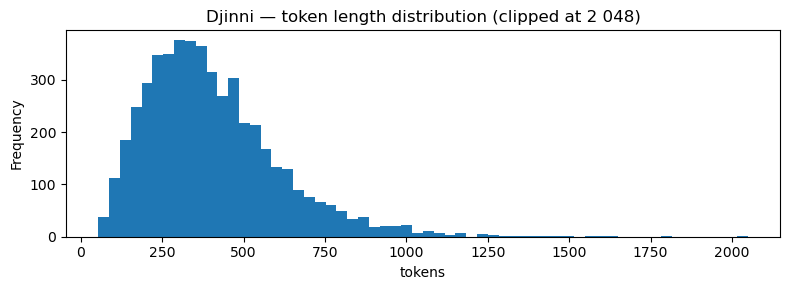

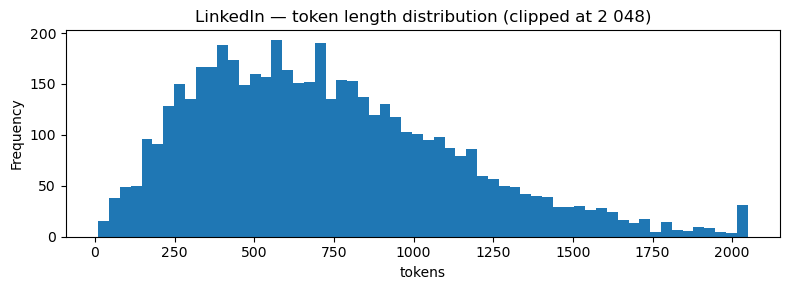

,Dataset,Sample size,Mean tokens,Median tokens,P90,P95,P99,Max,% > 512,% > 1024
0,Djinni,5000,406.0,370.0,672,796,1057,2875,24.9,1.2
1,LinkedIn,5000,730.3,674.0,1284,1495,1897,3038,65.5,21.9


In [40]:
MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"  # adjust if you choose another model
SAMPLE_FOR_TOKEN_ANALYSIS = 5000

MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"  # adjust if you choose another model
SAMPLE_FOR_TOKEN_ANALYSIS = 5000

try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"Loaded tokenizer: {MODEL_NAME}\n")

    def count_tokens_batch(texts, batch_size=128):
        counts = []
        for i in range(0, len(texts), batch_size):
            batch = [str(t) for t in texts[i:i + batch_size]]
            enc = tokenizer(batch, add_special_tokens=True, truncation=False)
            counts.extend(len(ids) for ids in enc["input_ids"])
        return counts

    token_rows = []
    for dataset_name, col in target_cols.items():
        non_null = datasets[dataset_name][col].dropna().astype(str)
        sample   = non_null.sample(min(SAMPLE_FOR_TOKEN_ANALYSIS, len(non_null)), random_state=42)
        counts   = pd.Series(count_tokens_batch(sample.tolist()), name="tokens")

        token_rows.append({
            "Dataset":        dataset_name,
            "Sample size":    len(sample),
            "Mean tokens":    round(counts.mean(), 1),
            "Median tokens":  round(counts.median(), 1),
            "P90":            int(counts.quantile(0.90)),
            "P95":            int(counts.quantile(0.95)),
            "P99":            int(counts.quantile(0.99)),
            "Max":            int(counts.max()),
            "% > 512":        round((counts > 512).mean() * 100, 1),
            "% > 1024":       round((counts > 1024).mean() * 100, 1),
        })

        ax = counts.clip(upper=2048).plot.hist(
            bins=60, figsize=(8, 3),
            title=f"{dataset_name} — token length distribution (clipped at 2 048)")
        ax.set_xlabel("tokens")
        plt.tight_layout()
        plt.show()

    display(pd.DataFrame(token_rows))

except Exception as e:
    print("Tokenizer analysis skipped — install transformers and verify model access.")
    print("Error:", repr(e))


### 7.1 Technical-term fragmentation

A practical concern for IT job descriptions: domain-specific terms like
`Kubernetes`, `CI/CD`, or `TypeScript` may be split into many sub-word tokens
by a general-purpose tokenizer. Heavy fragmentation means:

1. the model sees the concept spread across more positions → harder to learn,
2. token budget is consumed faster than the character count suggests.

The cell below tokenises a sample of domain-critical terms and reports how many
tokens each one produces.


,term,n_tokens,sub-tokens
15,RabbitMQ,4,Rab | bit | M | Q
9,React.js,4,Re | act | . | js
0,Kubernetes,3,K | uber | netes
13,OpenTelemetry,3,Open | Tele | metry
18,ArgoCD,3,Ar | go | CD
3,PostgreSQL,3,Post | gre | SQL
4,Dockerfile,3,D | ocker | file
16,ElasticSearch,3,El | astic | Search
8,Terraform,3,Ter | ra | form
1,CI/CD,3,CI | / | CD


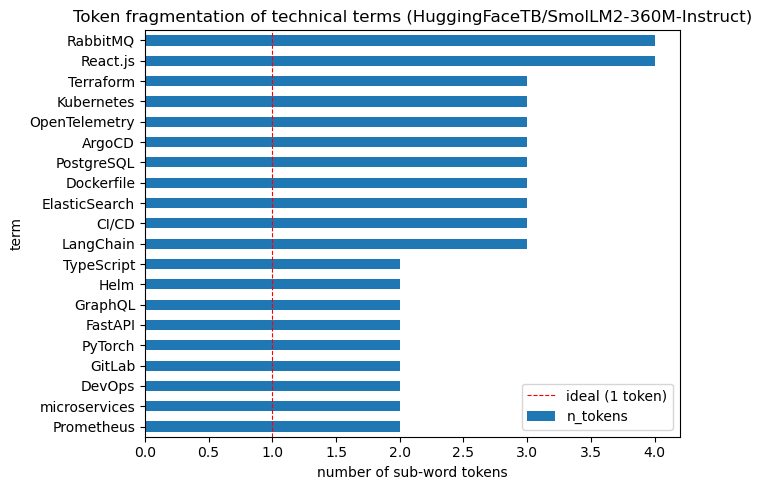

In [49]:
TECHNICAL_TERMS = [
    "Kubernetes", "CI/CD", "TypeScript", "PostgreSQL", "Dockerfile",
    "microservices", "DevOps", "GitLab", "Terraform", "React.js",
    "FastAPI", "PyTorch", "LangChain", "OpenTelemetry", "GraphQL",
    "RabbitMQ", "ElasticSearch", "Helm", "ArgoCD", "Prometheus"
]

try:
    rows_frag = []
    for term in TECHNICAL_TERMS:
        ids     = tokenizer.encode(term, add_special_tokens=False)
        tokens  = tokenizer.convert_ids_to_tokens(ids)
        rows_frag.append({
            "term":        term,
            "n_tokens":    len(ids),
            "sub-tokens":  " | ".join(tokens),
        })

    frag_df = pd.DataFrame(rows_frag).sort_values("n_tokens", ascending=False)
    display(frag_df)

    ax = frag_df.sort_values("n_tokens").plot.barh(
        x="term", y="n_tokens", legend=False, figsize=(7, 5),
        title=f"Token fragmentation of technical terms ({MODEL_NAME})")
    ax.set_xlabel("number of sub-word tokens")
    ax.axvline(1, color="red", linestyle="--", linewidth=0.8, label="ideal (1 token)")
    ax.legend()
    plt.tight_layout()
    plt.show()

except NameError:
    print("Tokenizer not loaded — run the cell above first.")

## 8. Semantic embedding analysis

This is one of the most important LLM-oriented analyses in the notebook. It checks whether job descriptions form meaningful semantic clusters.

If UX/design, DevOps/cloud, data/AI and security postings naturally cluster, this supports the assumption that a model can learn role-relevant patterns from the dataset.

The code first tries to use `sentence-transformers`. If unavailable, it falls back to TF-IDF + dimensionality reduction so that the notebook remains runnable in lighter environments.


In [42]:
import numpy as np
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer

SAMPLE_FOR_EMBEDDINGS = 1500
RANDOM_STATE = 42

sem_df = (
    djinni.dropna(subset=["Long Description", "Primary Keyword"])
    .sample(min(SAMPLE_FOR_EMBEDDINGS, len(djinni)), random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
texts_sem  = sem_df["Long Description"].astype(str).tolist()
labels_sem = sem_df["Primary Keyword"].astype(str).tolist()

try:
    from sentence_transformers import SentenceTransformer
    emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    embeddings = emb_model.encode(texts_sem, show_progress_bar=True,
                                   normalize_embeddings=True)
    embedding_source = "sentence-transformers/all-MiniLM-L6-v2"
except Exception as e:
    print("sentence-transformers unavailable — falling back to TF-IDF + SVD.")
    print("Note: clusters in this mode reflect shared vocabulary, not semantics.")
    print("Error:", repr(e))
    vec  = TfidfVectorizer(max_features=5000, stop_words="english", min_df=3)
    X    = vec.fit_transform(texts_sem)
    svd  = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
    embeddings = svd.fit_transform(X)
    embedding_source = "TF-IDF + TruncatedSVD (vocabulary overlap, not semantics)"

print("Embedding source:", embedding_source)
print("Matrix shape    :", embeddings.shape)



Batches: 100%|██████████| 47/47 [00:01<00:00, 27.65it/s]

Embedding source: sentence-transformers/all-MiniLM-L6-v2
Matrix shape    : (1500, 384)


### 8.1 2D projection of semantic clusters

This visualisation is not used as a model metric. It is an exploratory diagnostic to understand whether the dataset contains separable role/domain families.


c:\Users\user\anaconda30\envs\torch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


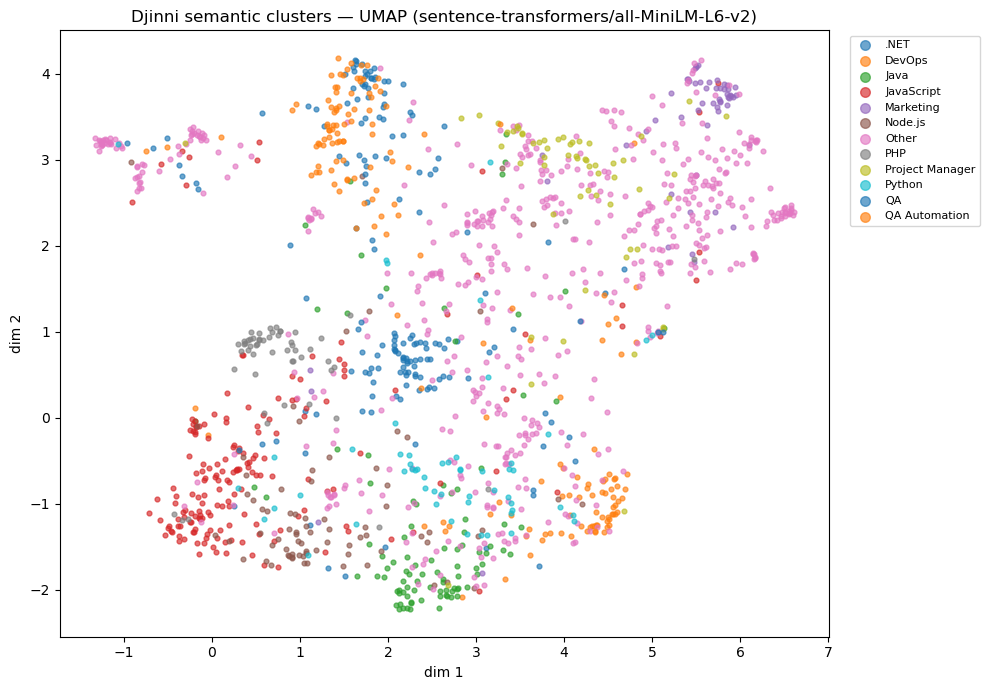

In [43]:
top_label_count = 12
top_labels  = pd.Series(labels_sem).value_counts().head(top_label_count).index
plot_labels = [x if x in top_labels else "Other" for x in labels_sem]

try:
    import umap
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=RANDOM_STATE)
    coords  = reducer.fit_transform(embeddings)
    method  = "UMAP"
except Exception as e:
    print("UMAP unavailable — falling back to PCA.")
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(embeddings)
    method = "PCA"

plot_df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "label": plot_labels})

fig, ax = plt.subplots(figsize=(10, 7))
for label, grp in plot_df.groupby("label"):
    ax.scatter(grp["x"], grp["y"], s=12, alpha=0.65, label=label)
ax.set_title(f"Djinni semantic clusters — {method} ({embedding_source})")
ax.set_xlabel("dim 1");  ax.set_ylabel("dim 2")
ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



### 8.2 Nearest-neighbour inspection

Cluster plots can be subjective. Nearest-neighbour examples provide a more concrete check: for a selected posting, do the closest descriptions refer to similar roles/domains?


In [44]:
from sklearn.metrics.pairwise import cosine_similarity

# Normalise once
norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
E_norm = embeddings / np.maximum(norms, 1e-12)

def show_neighbours(query_idx, n=5):
    sims   = cosine_similarity(E_norm[query_idx:query_idx+1], E_norm).ravel()
    nbrs   = sims.argsort()[::-1][1:n+1]
    print(f"{'='*70}")
    print(f"QUERY  #{query_idx}  |  role/domain: {labels_sem[query_idx]}")
    print(texts_sem[query_idx][:500], "...\n")
    for rank, idx in enumerate(nbrs, 1):
        print(f"  #{rank} | sim={sims[idx]:.3f} | role/domain: {labels_sem[idx]}")
        print(" ", texts_sem[idx][:300], "...\n")

# Pick one representative index for each target domain.
# The search below selects the first occurrence of each keyword in the sample.
target_domains = ["DevOps", "Data Science", "UI/UX Designer"]
for domain in target_domains:
    hits = [i for i, l in enumerate(labels_sem) if domain.lower() in l.lower()]
    if hits:
        show_neighbours(hits[0])
    else:
        print(f"Domain '{domain}' not found in sample — try adjusting the list.")



QUERY  #27  |  role/domain: DevOps
About:
Our customer implements the optimal, secured cloud architecture with the optimal cost for the company's services and specializes in clients who are considering, planning, or actively moving to cloud computing.

Technologies: AWS Lambda, Google Cloud Platform, CI/CD, K8s, Jenkins, Python.

Responsibilities:
- Working on GCP / AWS Cloud environment;
- Performing DevOps for the client including CICD / Automation process;
- Security configuration;
- Building and implementing Cloud Pr ...

  #1 | sim=0.797 | role/domain: DevOps
  We believe in innovation, so our vision is to build a tier-1 cloud operation that is fully automated and cloud agnostic. Our architecture is K8S based, so we need to have a strong execution of environment management, scalability, resiliency, redundancy and security. As a leader your role will be to  ...

  #2 | sim=0.794 | role/domain: DevOps
  Some of the major responsibilities include managing and extending our cloud infr